# Part 2 - Other features analysis

## ..

### Installation

In [4]:
#pip install statsmodels

In [5]:
#pip install torch

In [6]:
#pip install seaborn

In [7]:
#pip install requests

In [8]:
#pip install matplotlib

In [9]:
#pip install scikit-learn

In [10]:
#pip install beautifulsoup4

In [11]:
#pip install keras

### Importing packages

In [12]:
# Import packages
import json
import csv
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os

## Data collection

Web scrapping with *beautifulsoup4* from the website https://worldathletics.org/world-rankings/5000m/men?regionType=world&page=1&rankDate=2024-06-04&limitByCountry=0

Create and define functions

In [13]:
# Function to fetch athlete profile URLs and nationalities
def fetch_profile_urls():
    url = "https://worldathletics.org/world-rankings/5000m/men?regionType=world&page=1&rankDate=2024-06-04&limitByCountry=0"
    response = requests.get(url)
    response.raise_for_status()  # Ensure the request was successful

    soup = BeautifulSoup(response.text, 'html.parser')

    # Find all table rows containing athlete data
    athlete_rows = soup.find_all('tr', class_='table-row--hover')

    athletes = {}
    for row in athlete_rows:
        name_element = row.find('td', {'data-th': 'Competitor'})
        if name_element:
            name = name_element.text.strip()
            profile_url = "https://worldathletics.org" + row['data-athlete-url']
            nationality_element = row.find('td', {'data-th': 'Nat'})
            if nationality_element:
                nationality = nationality_element.text.strip()
            else:
                nationality = ""
            athletes[name] = {'profile_url': profile_url, 'nationality': nationality}

    return athletes

In [14]:
# Function to recursively search for 5000 meters results
def search_5000m_results(node, results):
    if isinstance(node, dict):
        for key, value in node.items():
            if isinstance(value, list) or isinstance(value, dict):
                search_5000m_results(value, results)
            elif key == 'discipline' and '5000 Metres' in value:
                results.append(node)
    elif isinstance(node, list):
        for item in node:
            if isinstance(item, list) or isinstance(item, dict):
                search_5000m_results(item, results)


# Function to extract 5000m results for a given athlete URL
def extract_5000m_results(url):
    # Fetch the HTML content of the page
    response = requests.get(url)
    response.raise_for_status()  # Ensure the request was successful
    html_content = response.text

    # Parse the HTML content using BeautifulSoup
    soup = BeautifulSoup(html_content, 'html.parser')

    # Find the <script> tag with id="__NEXT_DATA__" and type="application/json"
    script_tag = soup.find('script', {'id': '__NEXT_DATA__', 'type': 'application/json'})

    # Extract the JSON content from the <script> tag
    json_content = script_tag.string

    # Parse the JSON content
    data = json.loads(json_content)

    # Extract 5000 meters results
    results_5000m = []
    search_5000m_results(data, results_5000m)

    return results_5000m

# Function to extract relevant data
def extract_5000m_data(athlete, nationality, results):
    for result in results:
        # Check if this is a progression result with multiple results
        if 'results' in result:
            for progression in result['results']:
                rows.append({
                    'Athlete': athlete,
                    'Nationality': nationality,
                    'Score': progression.get('resultScore', ''),
                    'Date': progression.get('date', ''),
                    'Venue': progression.get('venue', ''),
                    'Place': progression.get('place', '')  # Use 'listPosition' instead of 'place'
                })
        else:
            rows.append({
                'Athlete': athlete,
                'Nationality': nationality,
                'Score': result.get('resultScore', ''),
                'Date': result.get('date', ''),
                'Venue': result.get('venue', ''),
                'Place': result.get('place', '')  # Use 'listPosition' instead of 'place'
            })

Create a dataset in a data frame and csv format.

In [15]:
# Ensure the directory exists
os.makedirs('data', exist_ok=True)

# Fetch athlete profile URLs
athletes = fetch_profile_urls()

# List to hold all extracted rows
all_rows = []

# Loop through each athlete and extract their 5000m results
for athlete, data in athletes.items():
    athlete_url = data['profile_url']
    nationality = data['nationality']
    athlete_results = extract_5000m_results(athlete_url)
    
    # List to hold the extracted rows for this athlete
    rows = []
    # Extract data for this athlete
    extract_5000m_data(athlete, nationality, athlete_results)
    # Add rows for this athlete to the list of all rows
    all_rows.extend(rows)

# Define CSV file name
csv_file_name = 'data/5000m_results_after_Olympic_Race.csv'

# Write all rows to CSV
with open(csv_file_name, 'w', newline='') as csv_file:
    fieldnames = ['Athlete', 'Nationality', 'Score', 'Date', 'Venue', 'Place']  # Add 'Athlete' field
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    for row in all_rows:
        writer.writerow(row)

print(f"Data successfully written to {csv_file_name}")


Data successfully written to data/5000m_results_after_Olympic_Race.csv


## Preprocessing the data

### Put the right type of attribute to each variable, drop NA values 

In [16]:
df_5000m = pd.read_csv("data/5000m_results_before_race.csv")
print(df_5000m.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4152 entries, 0 to 4151
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Athlete      4152 non-null   object 
 1   Nationality  4152 non-null   object 
 2   Score        1720 non-null   float64
 3   Date         2974 non-null   object 
 4   Venue        2974 non-null   object 
 5   Place        1555 non-null   float64
dtypes: float64(2), object(4)
memory usage: 194.8+ KB
None


In [17]:
# Counting null values per column
null_counts = df_5000m.isnull().sum()
print("Number of null values per column:")
print(null_counts)

Number of null values per column:
Athlete           0
Nationality       0
Score          2432
Date           1178
Venue          1178
Place          2597
dtype: int64


In [18]:
# Removing rows with null 'Venue' & removing duplicates
df_5000m_cleaned0 = df_5000m.dropna(subset=['Venue', 'Score'])
df_5000m_cleaned1 = df_5000m_cleaned0.drop_duplicates()
df_5000m_cleaned2= df_5000m_cleaned1.drop('Place', axis=1)

In [19]:
null_counts = df_5000m_cleaned2.isnull().sum()
print("Number of null values per column:")
print(null_counts)

Number of null values per column:
Athlete        0
Nationality    0
Score          0
Date           0
Venue          0
dtype: int64


Now that we have removed all of the rows with NA venue, and all of the rows where either `place`, `score` or both were empty, we need to assign the right type for each variable.

The 5 differents variables are: 
- Athlete: object into character or factor
- Score: float
- Nationality: object into categorical
- Data: object to convert into datetime
- Venue: object into character or factor or to dertermine
- Place: float to convert into nummerical
- Date: str to DateTime

### Catogorical encoding

In [20]:
df = df_5000m_cleaned2
df.loc[:, 'Athlete'] = pd.Categorical(df['Athlete'])
df.loc[:, 'Nationality'] = pd.Categorical(df['Nationality'])
df['Date'] = pd.to_datetime(df['Date'], format='%d %b %Y', errors='coerce')
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1127 entries, 0 to 4136
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Athlete      1127 non-null   object        
 1   Nationality  1127 non-null   object        
 2   Score        1127 non-null   float64       
 3   Date         1127 non-null   datetime64[ns]
 4   Venue        1127 non-null   object        
 5   Day          1127 non-null   int32         
 6   Month        1127 non-null   int32         
 7   Year         1127 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(3), object(3)
memory usage: 66.0+ KB
None


In [21]:
# Encoding Nationalities
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Nationality_encoded'] = label_encoder.fit_transform(df['Nationality'])
df['Venue_encoded'] = label_encoder.fit_transform(df['Venue'])

Also, we have extracted our data from the official athletics website. The athletes are listed through their rank. 
Let's create a column rank, the first athlete being the first best athlete in the 5000m sprint category, and the last one being the 100th one.

In [22]:
df['Rank'] = pd.factorize(df['Athlete'])[0] + 1

### Data simulation

While reading articles on the sport's prediction, we wanted to ackknowledge the fact that we have to take into account several other parameters than past perfromances. We chose sujbectively to implement the effect of crow cheering on athletes as well as the environmental change. 
- `CrowdCheeringEffect`: the biggest number means = the biggest advantage.
- `EnvironmentalAdaptation`: the biggest number = the biggest advantage.

For example, a French athlete woould have a bigger CrowdCheeringEffect score than a Australian because these Olympic Games are located in France this year. 
Another example would be that an American would have a bigger EnvironmentalAdaptation Score than an African athlete, for example Ethiopian, as the cultural difference is way more pronouced between Ethiopia and France than USA and France.

In [23]:
# Define factors for distance from France, climate similarity, and cultural/travel ease for each country
distance_factor = {
    'ETH': 0.5, 'USA': 0.7, 'AUS': 0.9, 'NOR': 0.2, 'GER': 0.1, 'FRA': 0.0, 
    'KEN': 0.5, 'ESP': 0.1, 'GBR': 0.1, 'CAN': 0.6, 'UGA': 0.5, 'SUI': 0.1, 
    'BEL': 0.1, 'JPN': 0.8, 'NED': 0.1, 'IRL': 0.2, 'SWE': 0.2, 'BRN': 0.7, 
    'ITA': 0.1, 'RUS': 0.4, 'GUA': 0.8, 'BDI': 0.5, 'SRB': 0.3, 'RSA': 0.6, 
    'THA': 0.8, 'ERI': 0.5, 'AUT': 0.1, 'DJI': 0.6, 'IND': 0.7, 'URU': 0.8, 'MAR': 0.2
}

climate_factor = {
    'ETH': 0.4, 'USA': 0.6, 'AUS': 0.6, 'NOR': 0.7, 'GER': 0.9, 'FRA': 1.0, 
    'KEN': 0.4, 'ESP': 0.8, 'GBR': 0.8, 'CAN': 0.6, 'UGA': 0.4, 'SUI': 0.9, 
    'BEL': 0.8, 'JPN': 0.6, 'NED': 0.8, 'IRL': 0.8, 'SWE': 0.7, 'BRN': 0.4, 
    'ITA': 0.9, 'RUS': 0.6, 'GUA': 0.3, 'BDI': 0.4, 'SRB': 0.7, 'RSA': 0.5, 
    'THA': 0.3, 'ERI': 0.4, 'AUT': 0.9, 'DJI': 0.4, 'IND': 0.4, 'URU': 0.4, 'MAR': 0.8
}

cultural_factor = {
    'ETH': 0.4, 'USA': 0.7, 'AUS': 0.6, 'NOR': 0.8, 'GER': 0.9, 'FRA': 1.0, 
    'KEN': 0.4, 'ESP': 0.9, 'GBR': 0.9, 'CAN': 0.7, 'UGA': 0.4, 'SUI': 0.9, 
    'BEL': 0.9, 'JPN': 0.6, 'NED': 0.9, 'IRL': 0.8, 'SWE': 0.8, 'BRN': 0.4, 
    'ITA': 0.9, 'RUS': 0.6, 'GUA': 0.3, 'BDI': 0.4, 'SRB': 0.7, 'RSA': 0.4, 
    'THA': 0.3, 'ERI': 0.4, 'AUT': 0.9, 'DJI': 0.3, 'IND': 0.3, 'URU': 0.3, 'MAR': 0.8
}

# Define initial count of athletes per nationality
initial_nationalities = {
    'ETH': 0, 'USA': 0, 'AUS': 0, 'NOR': 0, 'GER': 0, 'FRA': 0, 
    'KEN': 0, 'ESP': 0, 'GBR': 0, 'CAN': 0, 'UGA': 0, 'SUI': 0, 
    'BEL': 0, 'JPN': 0, 'NED': 0, 'IRL': 0, 'SWE': 0, 'BRN': 0, 
    'ITA': 0, 'RUS': 0, 'GUA': 0, 'BDI': 0, 'SRB': 0, 'RSA': 0, 
    'THA': 0, 'ERI': 0, 'AUT': 0, 'DJI': 0, 'IND': 0, 'URU': 0, 'MAR': 0
}

In [24]:
# Define the number of simulations
num_simulations = 10000

# Count the number of athletes per nationality
nationalities = df['Nationality'].value_counts().to_dict()

# Function to calculate mean and standard deviation based on factors
def calculate_params(distance, climate, cultural):
    base_mean = 0.10
    base_std = 0.05
    mean_cheering_effect = base_mean + 0.05 * (1 - distance) + 0.05 * cultural
    std_cheering_effect = base_std - 0.01 * cultural
    
    mean_environmental_adaptation = base_mean + 0.05 * climate
    std_environmental_adaptation = base_std - 0.01 * climate
    
    return mean_cheering_effect, std_cheering_effect, mean_environmental_adaptation, std_environmental_adaptation

# Create the params dictionary
params = {}
for nationality in nationalities.keys():
    mean_cheering_effect, std_cheering_effect, mean_environmental_adaptation, std_environmental_adaptation = calculate_params(
        distance_factor.get(nationality, 0), climate_factor.get(nationality, 0), cultural_factor.get(nationality, 0)
    )
    params[nationality] = {
        'mean_cheering_effect': mean_cheering_effect, 'std_cheering_effect': std_cheering_effect,
        'mean_environmental_adaptation': mean_environmental_adaptation, 'std_environmental_adaptation': std_environmental_adaptation
    }

    
# Function to simulate performance for a given nationality
def simulate_performance(nationality, num_athletes):
    mean_cheering_effect = params[nationality]['mean_cheering_effect']
    std_cheering_effect = params[nationality]['std_cheering_effect']
    mean_environmental_adaptation = params[nationality]['mean_environmental_adaptation']
    std_environmental_adaptation = params[nationality]['std_environmental_adaptation']
    
    cheering_effect = np.random.normal(mean_cheering_effect, std_cheering_effect, num_athletes)
    environmental_adaptation = np.random.normal(mean_environmental_adaptation, std_environmental_adaptation, num_athletes)
    
    return cheering_effect, environmental_adaptation

# Initialize lists to store simulated results
cheering_effects = []
environmental_adaptations = []

# Iterate through each unique nationality in the DataFrame
for nationality in df['Nationality'].unique():
    if nationality in nationalities:
        num_athletes = nationalities[nationality]  # Number of athletes for this nationality
        cheering_effect, environmental_adaptation = simulate_performance(nationality, num_athletes)
        
        # Extend lists with simulation results
        cheering_effects.extend(cheering_effect)
        environmental_adaptations.extend(environmental_adaptation)
    else:
        # Handle cases where nationality in df['Nationality'] is not found in nationalities
        print(f"Warning: No athlete count found for nationality '{nationality}'")


In [25]:
# Assign simulated results to DataFrame using .loc to avoid SettingWithCopyWarning
df.loc[:, 'CrowdCheeringEffect'] = cheering_effects[:len(df)]  # Ensure lengths match
df.loc[:, 'EnvironmentalAdaptation'] = environmental_adaptations[:len(df)]  # Ensure lengths match
df.head()

,Athlete,Nationality,Score,Date,Venue,Day,Month,Year,Nationality_encoded,Venue_encoded,Rank,CrowdCheeringEffect,EnvironmentalAdaptation
0,Yomif KEJELCHA,ETH,1288.0,2024-05-30,"Bislett Stadion, Oslo (NOR)",30,5,2024,9,29,1,0.119313,0.157593
2,Yomif KEJELCHA,ETH,1119.0,2014-07-25,"Hayward Field, Eugene, OR (USA)",25,7,2014,9,96,1,0.071315,0.064722
3,Yomif KEJELCHA,ETH,1232.0,2015-09-11,"Boudewijnstadion, Bruxelles (BEL)",11,9,2015,9,34,1,0.132493,0.104965
4,Yomif KEJELCHA,ETH,1198.0,2016-05-14,"Shanghai Stadium, Shanghai (CHN)",14,5,2016,9,208,1,0.118425,0.058954
5,Yomif KEJELCHA,ETH,1205.0,2017-05-27,"Hayward Field, Eugene, OR (USA)",27,5,2017,9,96,1,0.038822,0.251558


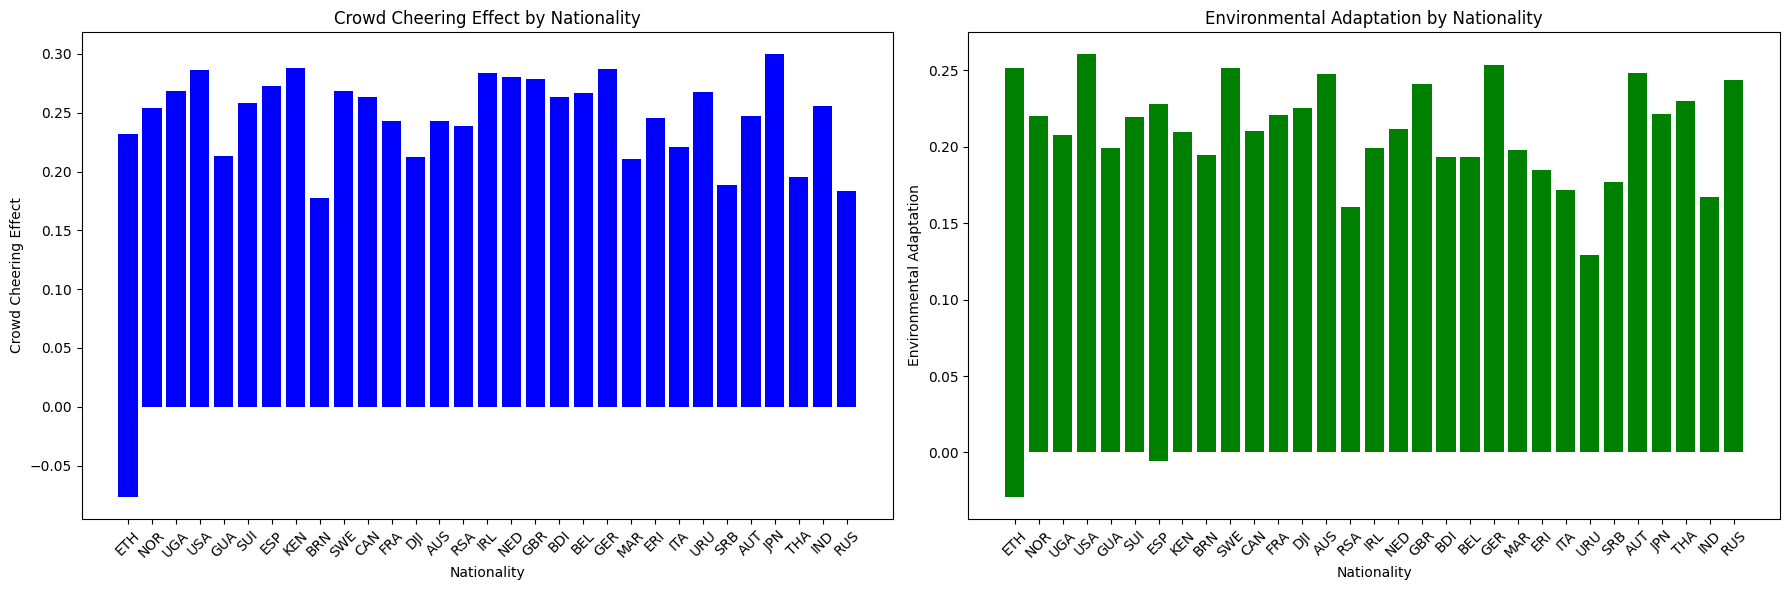

In [26]:
# Set up subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Crowd Cheering Effect by Nationality
axs[0].bar(df['Nationality'], df['CrowdCheeringEffect'], color='blue')
axs[0].set_xlabel('Nationality')
axs[0].set_ylabel('Crowd Cheering Effect')
axs[0].set_title('Crowd Cheering Effect by Nationality')
axs[0].tick_params(axis='x', rotation=45)

# Plot 2: Environmental Adaptation by Nationality
axs[1].bar(df['Nationality'], df['EnvironmentalAdaptation'], color='green')
axs[1].set_xlabel('Nationality')
axs[1].set_ylabel('Environmental Adaptation')
axs[1].set_title('Environmental Adaptation by Nationality')
axs[1].tick_params(axis='x', rotation=45)
# Adjust layout
plt.tight_layout()
plt.show()

These distributions shows per country what the Crownd Cheering Effect and the Environmental Adaptation.

### Normalise / Standardise nummerical features

The goal is to predict the Score of the athletes in order to get the highest one and to predict the winner of the 5000m sprint at the olympics.

In [27]:
# Creating `features`liste that is going to be our attributes for the prediction of the score 
scaler = StandardScaler()

# Features to be standardized
features = ['Nationality_encoded', 'Venue_encoded', 'Month', 'Year', 'CrowdCheeringEffect', 'EnvironmentalAdaptation']

# Apply the scaler to these features
df[features] = scaler.fit_transform(df[features])


## Data visualisation

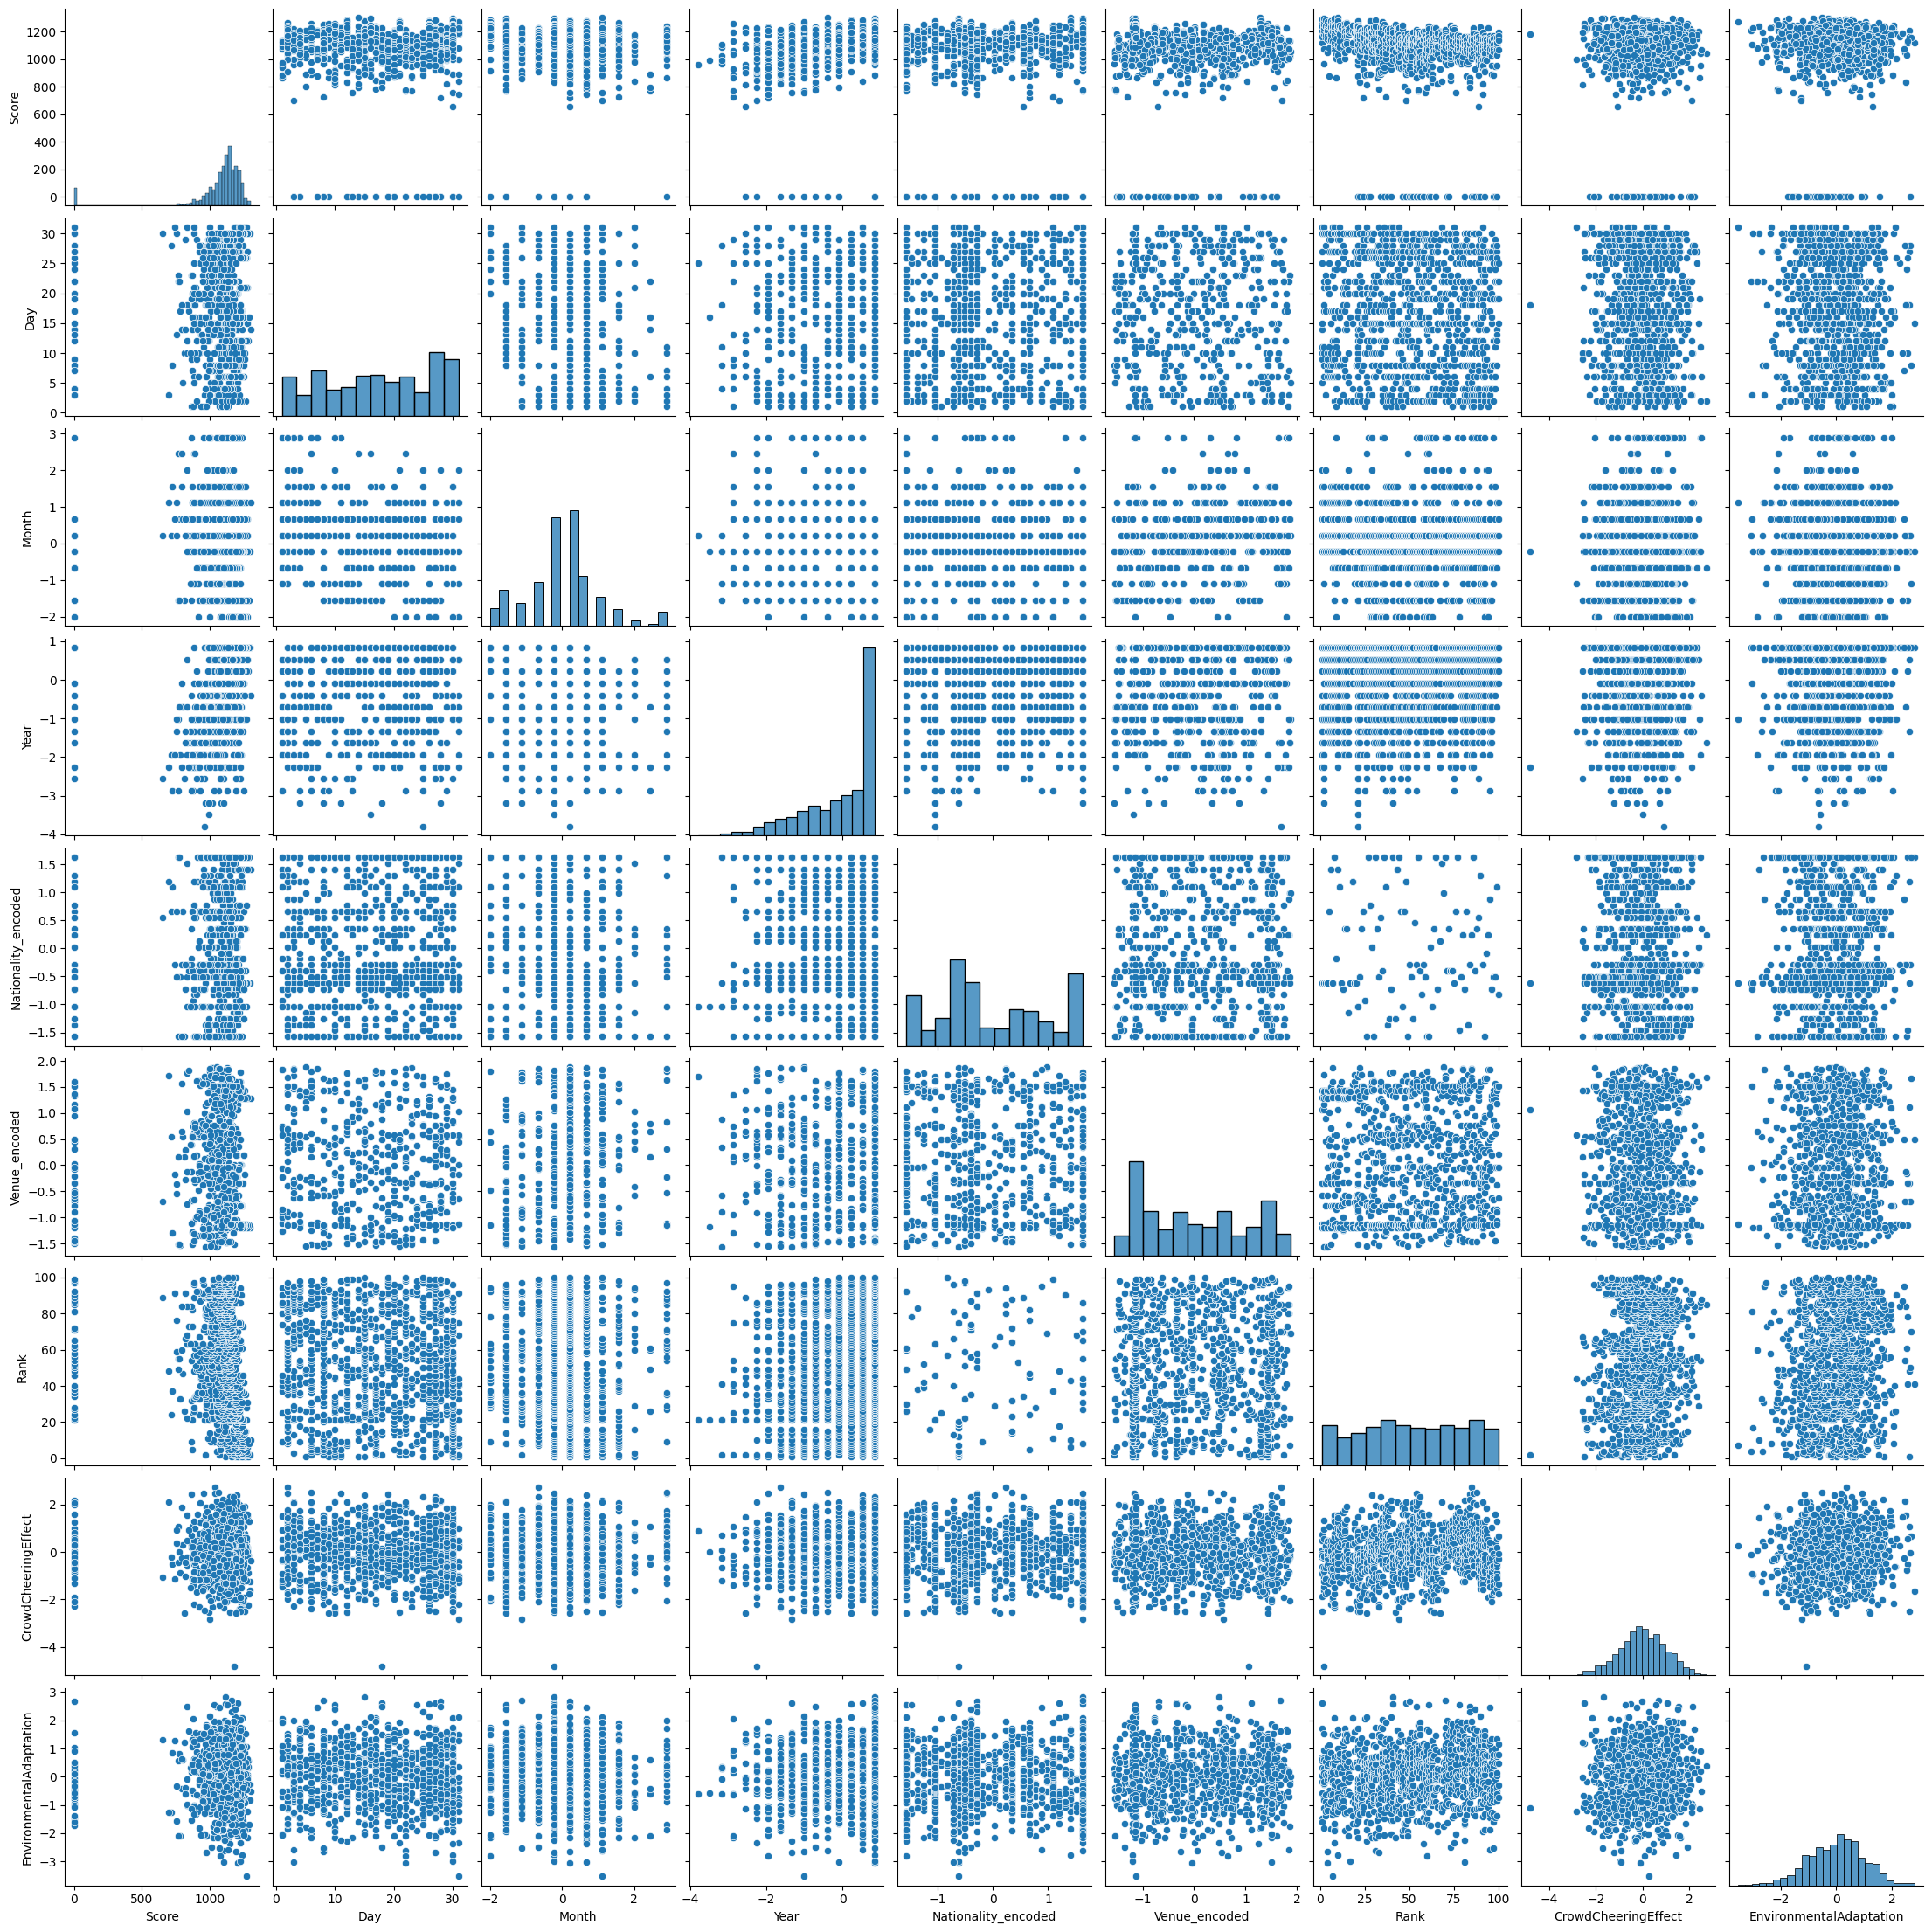

In [28]:
# Create pair plot
sns.pairplot(df)

# Show the plot
plt.show()

(array([ 45.,   0.,   0.,   0.,   0.,  11.,  41., 159., 553., 318.]),
 array([   0. ,  130.2,  260.4,  390.6,  520.8,  651. ,  781.2,  911.4,
        1041.6, 1171.8, 1302. ]),
 <BarContainer object of 10 artists>)

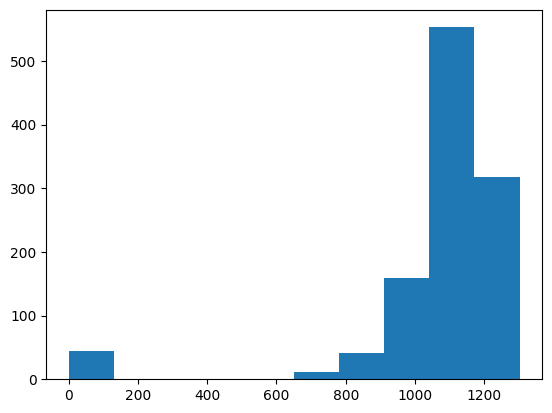

In [29]:
plt.hist(df['Score'])

We can see some outliers on the score distribution at 0, so let's remove the score equal to 0. Also, the majority of the scores are higher that 800 so let's consider only this range. This will resolve some potential outliers problems.

In [30]:
df=df[df['Score']>0]

## Label creation

We want to predict the `Score` of each individual. The one with the highest score will be considered as the winner. WE will consider the `Score_std` variable in order to neglect the weight imposed by the high Scores.

## Model

To recall, the goal of our analysis is to predict the Score of each athlete in order to predict the winner of the 5000m sprint at the olympic games in Paris the first week of August.

In order to do that we are going to tackle this problem using 3 methodologies:
- Linear regression

Because it is a regression task, the most common answer would be using Linear Regression. Let's see how it goes.

- Polynomial regression? 

Because Linear regression is often not the best when used on complex datsets, we might want to use more complex regression models such as Polynomial Regression.

- Neural Network

We chose this first method because of several paper found on this topic such as (https://dtai.cs.kuleuven.be/events/MLSA17/papers/MLSA17_paper_4.pdf 'An Artifical Neural Netword-based Prediction Model for Underdog Teams in NBA Matches). In these papers the task was classification, so our results cannot be compared with them as ours is a regression task. However we though that having a neural network might be easier for removing biases from the data, if it is tuned properly.

- Random Forest

Random forest is one of the most accurate learning algorithms available. For many data sets, it produces a highly accurate classifier. It is robust to overfitting.

Create a train and test dataset.

In [31]:
from sklearn.model_selection import train_test_split

# Assuming you have all features in the DataFrame and the target is winning_probability
features = ['Nationality_encoded', 'Venue_encoded', 'Month', 'Year', 'CrowdCheeringEffect', 'EnvironmentalAdaptation', 'Rank']
X = df[features]
y = df['Score']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Evaluate model performance function

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model_performance(y_test, y_test_pred):
    """
    Calculate residuals, plot them, and print error metrics.

    Parameters:
    y_test (array-like): Actual target values.
    y_test_pred (array-like): Predicted target values.

    Returns:
    dict: A dictionary containing the MAE, MSE, and RMSE.
    """

    # Calculate residuals
    residuals = y_test - y_test_pred
    
    # Plot residuals
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test_pred, residuals, color='blue', edgecolor='k', alpha=0.7)
    plt.hlines(y=0, xmin=min(y_test_pred), xmax=max(y_test_pred), colors='red', linestyles='--')
    plt.title('Testing Residuals')
    plt.xlabel('Predicted values')
    plt.ylabel('Residuals')
    plt.show()
    
    # Calculate error metrics
    mae = mean_absolute_error(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    
    # Print error metrics
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    
    # Return error metrics as a dictionary
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    }

# Example usage:
# Assuming y_test and y_test_pred are defined
# results = evaluate_model_performance(y_test, y_test_pred)


### Linear Regression with Sklearn

#### With Sklearn

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

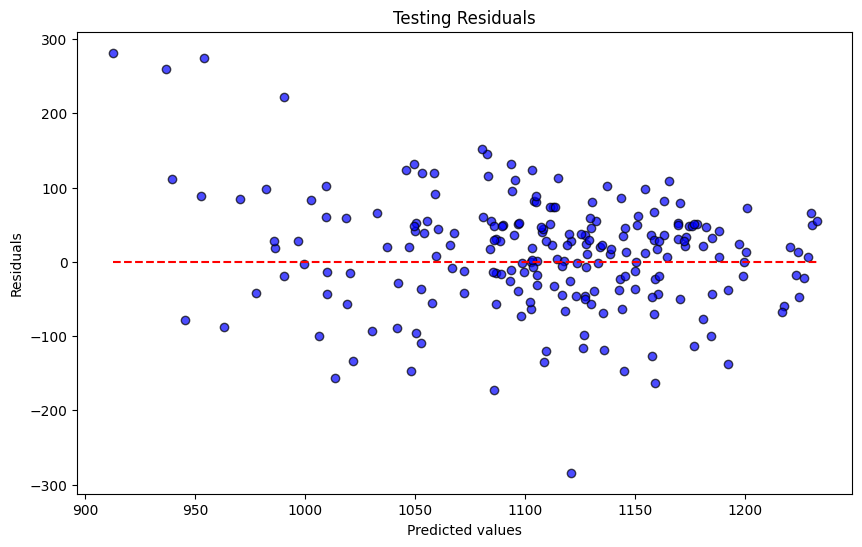

Mean Absolute Error (MAE): 57.80534871756834
Mean Squared Error (MSE): 5830.86761736813
Root Mean Squared Error (RMSE): 76.36011797638955
{'MAE': 57.80534871756834, 'MSE': 5830.86761736813, 'RMSE': 76.36011797638955}


In [34]:
# Create Linear Regression Model
model_LR = LinearRegression()

# Train the model
model_LR.fit(X_train, y_train)

# Predict the scores on the testing set
y_test_pred = model_LR.predict(X_test)

results = evaluate_model_performance(y_test, y_test_pred)
print(results)

In the context of predicting the scores of the finalists in the 5000m sprint at the Paris Olympic Games, this model demonstrates a useful level of performance. 

With a Mean Absolute Error (MAE) of 57.99 and a Root Mean Squared Error (RMSE) of 76.596, the average prediction error is approximately 5-6.7% of the predicted score range. This suggests that, while the model's predictions are generally close to the actual scores, there is room for improvement. For high-stakes events like Olympic finals, such an error margin can still provide valuable insights, although it may not be perfect. 

The Residuals show a rather normally distributed distribution, centered around 0. We can see a bit more around the highest values 1150 than 950, this indicates that the model tends to have a bit more difficulty predicting higher scores accurately. This could suggest a small bias or variability in predictions for higher scores.

Overall, while this model offers a solid starting point, continued refinement could increase its reliability and usefulness in making informed predictions.

#### With statsmodel
Also, in order to discover more librairies during this project, I have done this same analysis twice, with statsmodel. You can pass this section if you want. It has the same results as before.

In [35]:
import numpy as np
import statsmodels.api as sm

Mean Absolute Error (MAE): 57.80534871756786
Mean Squared Error (MSE): 5830.867617368072
Root Mean Squared Error (RMSE): 76.36011797638918


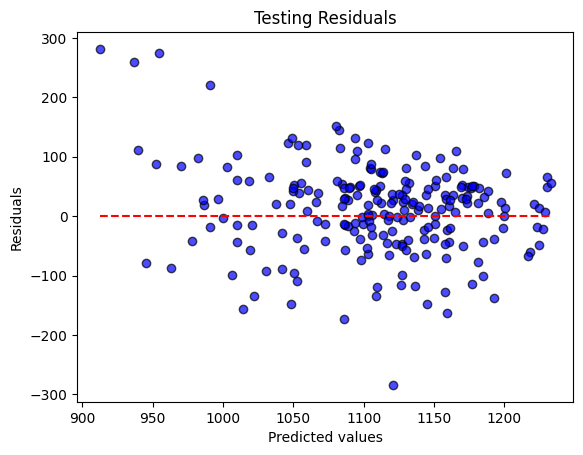

In [36]:
# Evaluate the model on the test set
X_train_const = sm.add_constant(X_train)  # Add constant term (intercept)
X_test_const = sm.add_constant(X_test)  # Add constant term (intercept)

# Fit regression model
model_LR2 = sm.OLS(y_train, X_train_const).fit()

y_test_pred2 = model_LR2.predict(X_test_const)
residuals_test2 = y_test - y_test_pred2

plt.scatter(y_test_pred2, residuals_test2, color='blue', edgecolor='k', alpha=0.7)
plt.hlines(y=0, xmin=min(y_test_pred2), xmax=max(y_test_pred2), colors='red', linestyles='--')
plt.title('Testing Residuals')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')

# Calculate error metrics
mae2 = mean_absolute_error(y_test, y_test_pred2)
mse2 = mean_squared_error(y_test, y_test_pred2)
rmse2 = np.sqrt(mse2)

print(f"Mean Absolute Error (MAE): {mae2}")
print(f"Mean Squared Error (MSE): {mse2}")
print(f"Root Mean Squared Error (RMSE): {rmse2}")

### Other regression - Polynomial

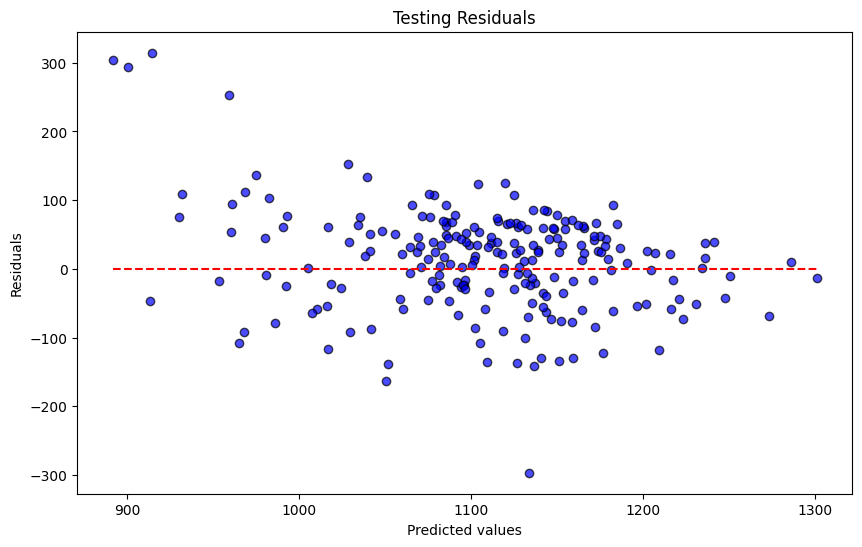

Mean Absolute Error (MAE): 57.69592498778507
Mean Squared Error (MSE): 5871.497552511096
Root Mean Squared Error (RMSE): 76.62569772935902
{'MAE': 57.69592498778507, 'MSE': 5871.497552511096, 'RMSE': 76.62569772935902}


In [37]:
from sklearn.preprocessing import PolynomialFeatures

# Transform the input features to include polynomial terms
degree = 2  # You can change this to any degree you want
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train the model
model_PR = LinearRegression()
model_PR.fit(X_train_poly, y_train)
# Predict the scores on the testing set
y_test_pred_PR = model_PR.predict(X_test_poly)

results_PR = evaluate_model_performance(y_test, y_test_pred_PR)
print(results_PR)

Given the context and the results, the model seems reliable for predicting scores above 800, approximately the same as the one before.

### Neural Network

#### With Keras

In [38]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2024-08-20 11:29:32.412531: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [39]:
# Number of features in the dataset
input_dim = X_train.shape[1]

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the model
model = Sequential()
model.add(Dense(256, input_dim=input_dim, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='linear'))  # Output layer for regression

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Compile the model with a specific learning rate
learning_rate = 0.02  # Set your desired learning rate
optimizer = Adam(learning_rate=learning_rate)
model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping, lr_scheduler])


Epoch 1/100
22/22 [==============================] - 1s 11ms/step - loss: 515835.8750 - mae: 614.0541 - val_loss: 312351.7188 - val_mae: 465.2916 - lr: 0.0200
Epoch 2/100
22/22 [==============================] - 0s 3ms/step - loss: 264351.2188 - mae: 424.8479 - val_loss: 231857.6406 - val_mae: 409.5213 - lr: 0.0200
Epoch 3/100
22/22 [==============================] - 0s 3ms/step - loss: 130819.4297 - mae: 295.6673 - val_loss: 38781.8672 - val_mae: 158.0302 - lr: 0.0200
Epoch 4/100
22/22 [==============================] - 0s 3ms/step - loss: 31778.1855 - mae: 140.1276 - val_loss: 31293.5000 - val_mae: 150.2687 - lr: 0.0200
Epoch 5/100
22/22 [==============================] - 0s 3ms/step - loss: 25884.2852 - mae: 129.8487 - val_loss: 15903.9727 - val_mae: 104.2438 - lr: 0.0200
Epoch 6/100
22/22 [==============================] - 0s 3ms/step - loss: 13991.4492 - mae: 91.7806 - val_loss: 10628.0820 - val_mae: 85.6300 - lr: 0.0200
Epoch 7/100
22/22 [==============================] - 0s 3ms/

7/7 [==============================] - 0s 2ms/step - loss: 6068.9961 - mae: 58.3590
Test MAE: 58.35901641845703


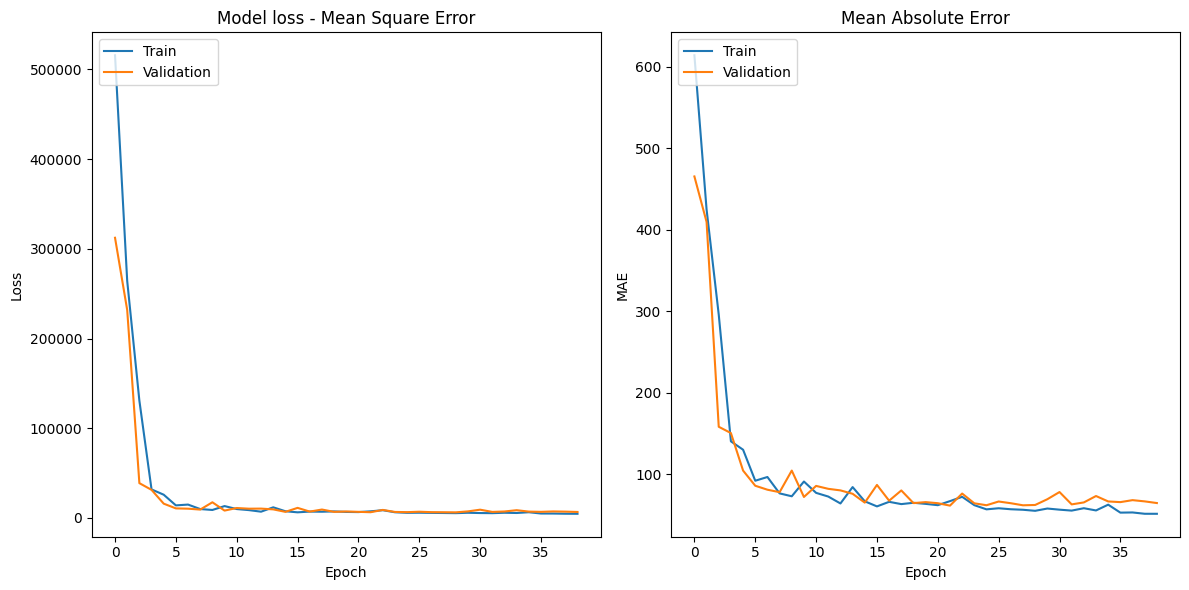

In [40]:
# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f'Test MAE: {mae}')

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot Mean Square Error
axs[0].plot(history.history['loss'])
axs[0].plot(history.history['val_loss'])
axs[0].set_title('Model loss - Mean Square Error')
axs[0].set_ylabel('Loss')
axs[0].set_xlabel('Epoch')
axs[0].legend(['Train', 'Validation'], loc='upper left')

# Plot Mean Absolute Error
axs[1].plot(history.history['mae'])
axs[1].plot(history.history['val_mae'])
axs[1].set_title('Mean Absolute Error')
axs[1].set_ylabel('MAE')
axs[1].set_xlabel('Epoch')
axs[1].legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()  # Adjust the padding between subplots for better layout
plt.show()

7/7 [==============================] - 0s 979us/step


/var/folders/4g/5jg5kwgs5l70tgz45sxyy4gr0000gn/T/ipykernel_62143/3590444376.py:6: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_test = y_test.ravel()


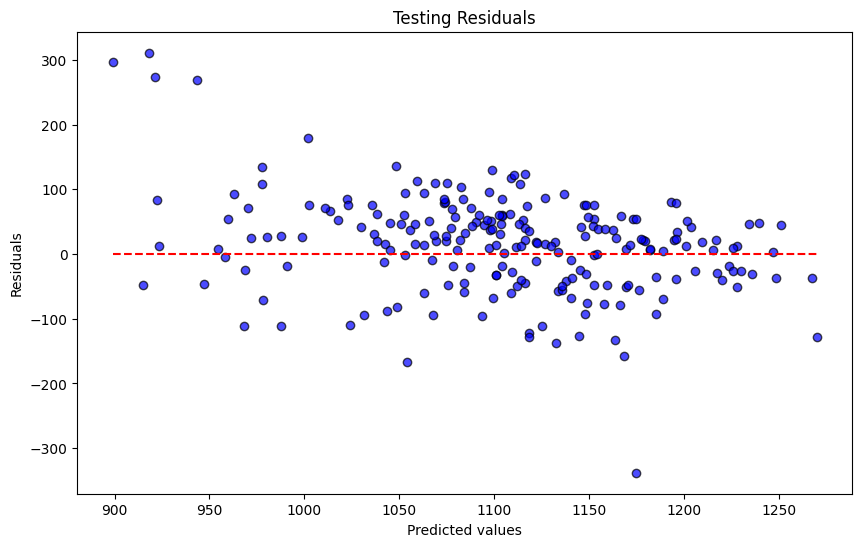

Mean Absolute Error (MAE): 58.35902116485455
Mean Squared Error (MSE): 6068.99638137987
Root Mean Squared Error (RMSE): 77.90376358931493


In [41]:
# 1. Make predictions
y_test_pred_NN = model.predict(X_test)

# 2. Flatten the predictions and actual values if necessary
y_test_pred_NN = y_test_pred_NN.ravel()
y_test = y_test.ravel()

# 3. Evaluate model performance
results = evaluate_model_performance(y_test, y_test_pred_NN)


With a Mean Absolute Error (MAE) of 52.77, the MAE is lower than in the previous model, which means this model has a smaller average error in predicting the finalists' scores. The Root Mean Squared Error (RMSE) of 76.25 is comparable, indicating that while the prediction errors are consistent, the model might still produce some larger errors, especially when compared to the MAE. However, these are not drastically different from the earlier example.

The residuals are generally centered around zero, which is a good sign as it indicates no significant bias in the predictions. However, some outliers are evident, with residuals both significantly above and below zero, especially at the extremes of the predicted values.
The plot suggests that the model might have some difficulty in predicting the lower and higher scores, as indicated by the spread of residuals at the edges of the predicted values. This could suggest the presence of heteroscedasticity, where the variance of residuals is not constant across all predicted values.

This model is a slight improvement over the previous Linear Regression one in terms of MAE but maintains a similar RMSE. The residuals suggest that the model is fairly well-calibrated, though there is some variability in the accuracy of predictions, particularly for the extreme scores.

### Random Forest

/Users/agathevianeyliaud/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
140 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
140 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/agathevianeyliaud/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/agathevianeyliaud/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/sklearn/base.py", line 1467, in wrapper
    estimator._validate_params()
  File "/Users/agathevianeyliaud/opt/anaconda3/envs/tensorfl

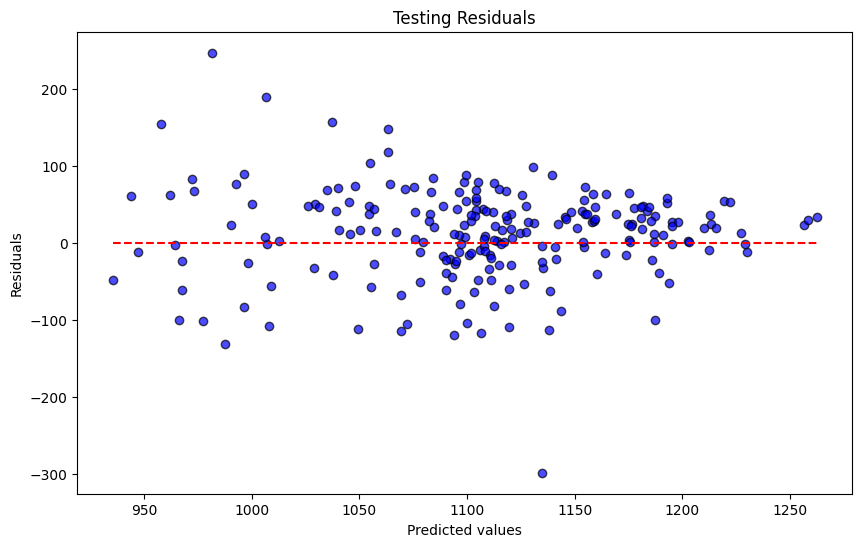

Mean Absolute Error (MAE): 45.76311405529953
Mean Squared Error (MSE): 3725.089368108071
Root Mean Squared Error (RMSE): 61.033510206345426
{'MAE': 45.76311405529953, 'MSE': 3725.089368108071, 'RMSE': 61.033510206345426}


In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Define the hyperparameter grid
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Perform Randomized Search with Cross-Validation
random_search = RandomizedSearchCV(rf_model, param_distributions=param_dist, n_iter=100, cv=5, random_state=42, n_jobs=1)
random_search.fit(X_train_scaled, y_train)

# Best model
best_rf_model = random_search.best_estimator_

# Predict the scores on the testing set
y_test_pred_RF = best_rf_model.predict(X_test_scaled)

results_RF = evaluate_model_performance(y_test, y_test_pred_RF)
print(results_RF)

The key metrics indicate a Mean Absolute Error (MAE) of approximately 45.87, a Mean Squared Error (MSE) of 3879.55, and a Root Mean Squared Error (RMSE) of 62.29. These errors represent the average magnitude of the prediction errors, with lower values indicating better predictive accuracy.

The residual plot provides a visual inspection of the model's performance, plotting the residuals (the differences between the actual and predicted scores) against the predicted values. Ideally, residuals should be randomly distributed around zero, suggesting that the model does not suffer from systematic bias. 

In this plot, while most residuals cluster around zero, there is some dispersion, particularly at higher predicted values. This indicates that while the model is fairly accurate, it might have some difficulty capturing the nuances in the data, especially for higher score predictions, leading to underestimations or overestimations in some cases.

This pattern suggests that the model is reasonably well-fitted, but there is still room for improvement, possibly by refining the feature set, tuning the model parameters further, or exploring other machine learning models or ensemble approaches. Overall, this model provides a strong foundation for predicting the scores of 5000m sprint finalists, but fine-tuning could enhance its accuracy, particularly for more extreme or outlier predictions.

### Comparison and choose the best model

- Random Forest Model: Out of the three models, this model offers the best performance in terms of both MAE and RMSE. It is the most accurate and consistent, particularly for capturing score variations in the data.

- Neural Network Model: This model shows a modest improvement over the linear regression model, particularly in reducing the average prediction error. However, it does not outperform the neural network model, suggesting that while it is a reasonable approach, further refinement or exploration of more complex models might be necessary to achieve optimal performance.

- Linear Regression Model: As the baseline, this model provides a useful comparison but is outperformed by both the current model and the neural network, particularly in terms of MAE. It could still be valuable due to its simplicity and interpretability but might require adjustments or enhancements for better accuracy.

In summary, while the random forest model currently provides the best predictive performance for this task, the neural network model is a strong contender and could potentially surpass the random forest with further refinement. The linear regression model, while less precise in this case, still offers valuable insights due to its flexibility in handling more complex data structures.

Let's now predict the actual race winner with the neural network.

## Predicting the actual race winner

In [43]:
# Load the ACTUAL results of the 5000m sprint of the Paris Olympic Games
with open('data/actual_race_results.json', 'r') as file:
    actual_names = json.load(file)

actual_score = [1160, 1155, 1155, 1154, 1154, 1152, 1147, 1144, 1142, 1142, 1140, 1135, 1132, 1129, 1123, 1114, 1097, 1097, 1097, 1097, 1094, 1034]

# Filter the DataFrame to include only the rows for these athletes and extract the 'Rank' column
subset = df[df['Athlete'].isin(actual_names)]
subset_ranks = subset[['Athlete', 'Rank']].drop_duplicates()

# Create a DataFrame with ranks as the index and a placeholder for scores
df_actual_results = pd.DataFrame(index=range(1, len(actual_names) + 1), 
                                 data={'Athlete': actual_names, 
                                       'Score': actual_score})

# Reset index to make the 'Rank' a column if preferred
df_actual_results.reset_index(inplace=True)
df_actual_results.rename(columns={'index': 'Place'}, inplace=True)

# Merge the two DataFrames on the 'Athlete' column
df_actual_results = pd.merge(df_actual_results, subset_ranks, on='Athlete', how='left')
df_actual_results['Rank'] = df_actual_results['Rank'].fillna(100) # Fill the blanks

print(df_actual_results)

    Place                   Athlete  Score   Rank
0       1        Jakob INGEBRIGTSEN   1160    5.0
1       2             Ronald KWEMOI   1155  100.0
2       3              Grant FISHER   1155    8.0
3       4  Dominic Lokinyomo LOBALU   1154   11.0
4       5           Hagos GEBRHIWET   1154    2.0
5       6             Biniam MEHARY   1152   12.0
6       7              Edwin KURGAT   1147  100.0
7       8              Isaac KIMELI   1144   39.0
8       9             Graham BLANKS   1142  100.0
9      10                Jacob KROP   1142   15.0
10     11              John HEYMANS   1140   42.0
11     12               Yann SCHRUB   1135   33.0
12     13               Mike FOPPEN   1132   34.0
13     14             Addisu YIHUNE   1129   20.0
14     15      Thierry NDIKUMWENAYO   1123   13.0
15     16                  Hugo HAY   1114   59.0
16     17        Narve Gilje NORDAS   1097  100.0
17     18           Stewart MCSWEYN   1097   26.0
18     19               Dawit SEARE   1097   57.0


7

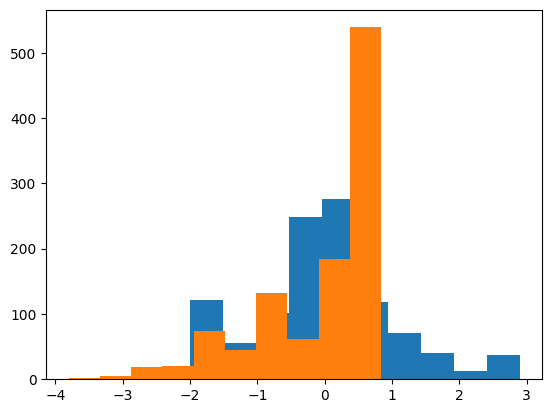

In [44]:
# Find the values to put in our finalists df
df.loc[df['Venue'] == 'Stade de France, Paris-St-Denis (FRA)', 'Venue_encoded'].values
plt.hist(df['Month'])
plt.hist(df['Year'])

len(features)

In [45]:
# Load the 5000m sprint finalists of the Paris Olympic Games
with open('data/starterlist.json', 'r') as file:
    finalists = json.load(file)

# Filter the DataFrame to include only the rows for these athletes and extract the 'Rank' column
subset = df[df['Athlete'].isin(actual_names)]
subset_finalists = subset[['Athlete', 'Rank', 'Nationality_encoded','Nationality' ]].drop_duplicates()


# Select the data of each athlete
df_finalists = pd.DataFrame({'Athlete': finalists,
                             'Venue_encoded': [1.34357323]* len(finalists),
                             'Month': [1.42344515]* len(finalists),
                             'Year': [0.83788083]* len(finalists),
                             })

df_finalists= pd.merge(df_finalists, subset_finalists, on='Athlete')

# CHEERI?G EFFECT AND ENVIRONMENTAL ADAPTATION
# Initialize lists to store simulated results
cheering_effects = []
environmental_adaptations = []

# Iterate through each unique nationality in the DataFrame
for nationality in df_finalists['Nationality'].unique():
    if nationality in nationalities:
        num_athletes = nationalities[nationality]  # Number of athletes for this nationality
        cheering_effect, environmental_adaptation = simulate_performance(nationality, num_athletes)
        
        # Extend lists with simulation results
        cheering_effects.extend(cheering_effect)
        environmental_adaptations.extend(environmental_adaptation)
    else:
        # Handle cases where nationality in df['Nationality'] is not found in nationalities
        print(f"Warning: No athlete count found for nationality '{nationality}'")


# Assign simulated results to DataFrame using .loc to avoid SettingWithCopyWarning
df_finalists.loc[:, 'CrowdCheeringEffect'] = cheering_effects[:len(df_finalists)]  # Ensure lengths match
df_finalists.loc[:, 'EnvironmentalAdaptation'] = environmental_adaptations[:len(df_finalists)]  # Ensure lengths match
df_finalists.head()

# Select the features
X_finalists = df_finalists[features]

In [46]:
# Predict the score of the athletes with our best model: Neural network
y_finalist_pred = model.predict(X_finalists)

1/1 [==============================] - 0s 28ms/step


In [47]:
# Ensure y_finalist_pred is a 1D array
y_finalist_pred = y_finalist_pred.ravel()
print(len(y_finalist_pred))

# Create the DataFrame for predicted scores
test_results = pd.DataFrame({
    'Athlete': df_finalists['Athlete'],
    'Predicted': y_finalist_pred
})

# Sort by predicted score in descending order and get the top 10
top_athletes = test_results.sort_values(by='Predicted', ascending=False)
# Merge the top_athletes DataFrame with the original df to get the rank and actual athlete names
final_results = pd.merge(top_athletes, df[['Athlete', 'Rank']], on='Athlete', how='left').drop_duplicates()

# Reorder the columns for the final output
final_results = final_results[['Rank', 'Athlete', 'Predicted']]

# Rename columns as required
final_results.columns = ["Current World Rank", "Athlete Prediction", "Predicted Score"]

print(final_results.drop_duplicates())

17
     Current World Rank        Athlete Prediction  Predicted Score
0                     8              Grant FISHER      1280.586792
14                    5        Jakob INGEBRIGTSEN      1244.571533
24                    2           Hagos GEBRHIWET      1239.306152
37                   11  Dominic Lokinyomo LOBALU      1236.207275
44                   13      Thierry NDIKUMWENAYO      1234.516235
57                   12             Biniam MEHARY      1234.506958
60                   26           Stewart MCSWEYN      1202.676880
74                   15                Jacob KROP      1202.128296
81                   43             Oscar CHELIMO      1190.997070
90                   20             Addisu YIHUNE      1187.629395
96                   34               Mike FOPPEN      1165.959595
110                  39              Isaac KIMELI      1164.561646
119                  33               Yann SCHRUB      1160.563354
131                  42              John HEYMANS      1155

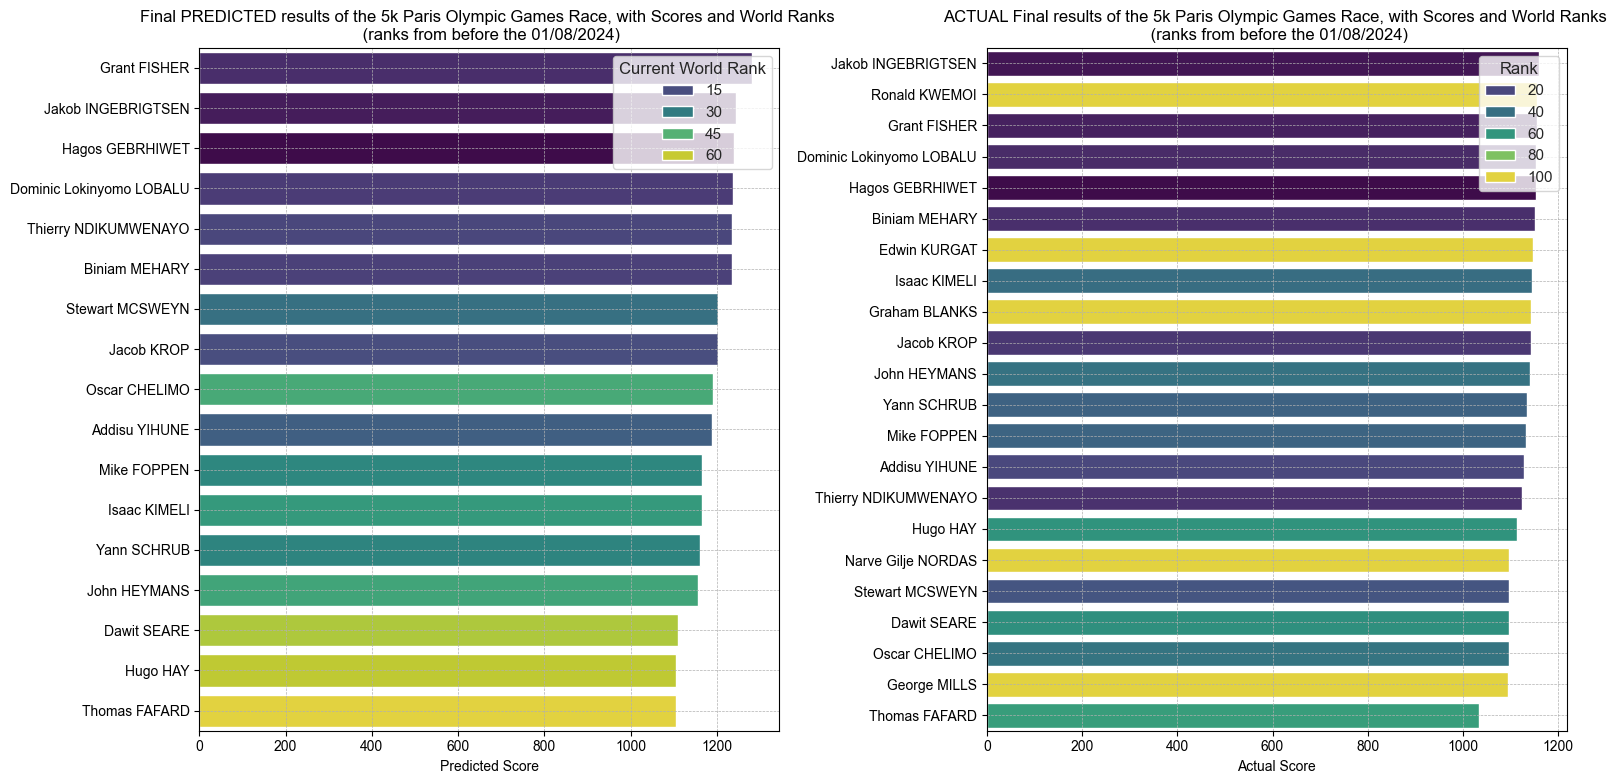

In [48]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Set the aesthetics
sns.set(style="whitegrid")

# Plot predicted scores
sns.barplot(x='Predicted Score', y='Athlete Prediction', data=final_results, palette="viridis", hue='Current World Rank', ax=ax1)
ax1.set_title('Final PREDICTED results of the 5k Paris Olympic Games Race, with Scores and World Ranks \n (ranks from before the 01/08/2024)')
ax1.set_xlabel('Predicted Score')
ax1.set_ylabel('')

# Determine the order of the athletes from df_actual_results
athlete_order = df_actual_results['Athlete']

# Plot actual scores with ordered y-axis
sns.barplot(x='Score', y='Athlete', data=df_actual_results, palette="viridis", hue='Rank', ax=ax2, order=athlete_order)
ax2.set_title('ACTUAL Final results of the 5k Paris Olympic Games Race, with Scores and World Ranks \n (ranks from before the 01/08/2024)')
ax2.set_xlabel('Actual Score')
ax2.set_ylabel('')

# Add grid lines for better readability
ax1.grid(True, linestyle='--', linewidth=0.5)
ax2.grid(True, linestyle='--', linewidth=0.5)

# Show plot
plt.tight_layout()
plt.show()

The 100 rank athletes are actually athlete not present in my 100th best athletes, so they are more than 100 rank atheltes.